### Cleaning Data

In [ ]:
import pandas as pd
import re
import string
import nltk

# Load dataset
data = pd.read_csv("dataset.csv")
data.info()
data.head(10)

# Copy data to df and rename column if needed
df = data.copy()
if 'text' in df.columns:
    df.rename(columns={'text': 'comment'}, inplace=True)

df.info()
df.head()

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile(
            "["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
            "]+", flags=re.UNICODE
        )
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
        return tweet
    else:
        return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
        return tweet
    else:
        return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

# Proses cleaning
df['cleaning'] = df['comment'].apply(remove_URL)
df['cleaning'] = df['cleaning'].apply(remove_usernames)
df['cleaning'] = df['cleaning'].apply(remove_html)
df['cleaning'] = df['cleaning'].apply(remove_emoji)
df['cleaning'] = df['cleaning'].apply(remove_symbols)
df['cleaning'] = df['cleaning'].apply(remove_numbers)

df.head(5)

: 

### Case folding

In [3]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,comment,cleaning,case_folding
0,yg setuju demo like,yg setuju demo like,yg setuju demo like
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk


### Normalisasi

In [4]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['comment','cleaning','case_folding']])
data.head()

,comment,cleaning,case_folding
0,yg setuju demo like,yg setuju demo like,yg setuju demo like
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk


In [5]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [6]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['comment','cleaning','case_folding','normalisasi']])
df.head(5)

,comment,cleaning,case_folding,normalisasi
0,yg setuju demo like,yg setuju demo like,yg setuju demo like,yang setuju demo like
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk


### Tokenization

In [7]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,comment,cleaning,case_folding,normalisasi,tokenize
0,yg setuju demo like,yg setuju demo like,yg setuju demo like,yang setuju demo like,"[yang, setuju, demo, like]"
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"[serius, bertanya, kalau, tidak, ada, dpr, sem..."
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"[menari, di, atas, penderitaan, rakyat]"
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]"
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"[tidak, usah, bayar, pajak, titikkkk]"


### Proses Stopword Removal

In [8]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sheva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Ubah hasil list jadi string
df['stopword removal'] = df['tokenize'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

df.head(5)

,comment,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,yg setuju demo like,yg setuju demo like,yg setuju demo like,yang setuju demo like,"[yang, setuju, demo, like]",setuju demo like
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"[serius, bertanya, kalau, tidak, ada, dpr, sem...",serius dpr orang hidup
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"[menari, di, atas, penderitaan, rakyat]",menari penderitaan rakyat
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]",dunia akhirat gue iklas byr pajak
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"[tidak, usah, bayar, pajak, titikkkk]",bayar pajak titikkkk


In [10]:
from collections import Counter

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

df_freq.to_csv('frekuensi_kata_awal.csv', index=False)
print("✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.")
df_freq.info()
df_freq.head(50)

✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10811 entries, 0 to 10810
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Kata       10811 non-null  object
 1   Frekuensi  10811 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 169.1+ KB


,Kata,Frekuensi
0,dpr,1781
1,juta,1710
2,ya,1674
3,rakyat,1511
4,gaji,920
5,beras,804
6,rumah,779
7,tunjangan,756
8,anggota,538
9,orang,453


In [11]:
hapus_kata = ['ya','sih','tau','biar']

# hapus kata dari teks
df['stopword removal'] = df['stopword removal'].apply(
    lambda x: ' '.join([kata for kata in x.split() if kata not in hapus_kata]))

df['stopword removal'].str.contains('|'.join(hapus_kata)).sum()

np.int64(4163)

In [12]:
# ---  Membuat kamus kata tidak baku -> kata baku
kamus_tidak_baku = {
    'dpr':'dewan perwakilan rakyat'
}

def perbaiki_kata(teks):
    kata_list = teks.split()
    hasil = [kamus_tidak_baku.get(kata, kata) for kata in kata_list]
    return ' '.join(hasil)

df['stopword removal'] = df['stopword removal'].astype(str).apply(perbaiki_kata)


In [13]:
from collections import Counter
import re

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

# df_freq.info()
df_freq.head(50)

,Kata,Frekuensi
0,rakyat,3292
1,dewan,1947
2,perwakilan,1803
3,juta,1710
4,gaji,920
5,beras,804
6,rumah,779
7,tunjangan,756
8,anggota,538
9,orang,453


### Wordcloud Setelah Preprocessing


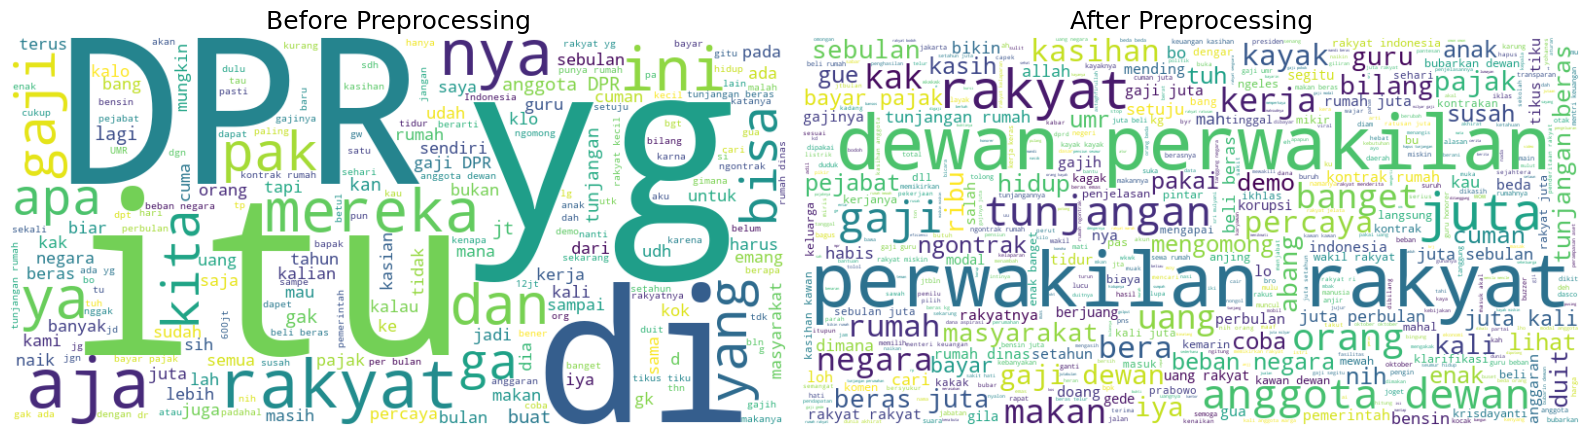

In [14]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# WordCloud Before
text_before = ' '.join(
    df['comment']
    .astype(str)
    .tolist()
)

wc_before = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_before)

# WordCloud After (dari kolom 'stopword removal')
text_after = ' '.join(
    [" ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
     for x in df['stopword removal'].astype(str)]
)

wc_after = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()

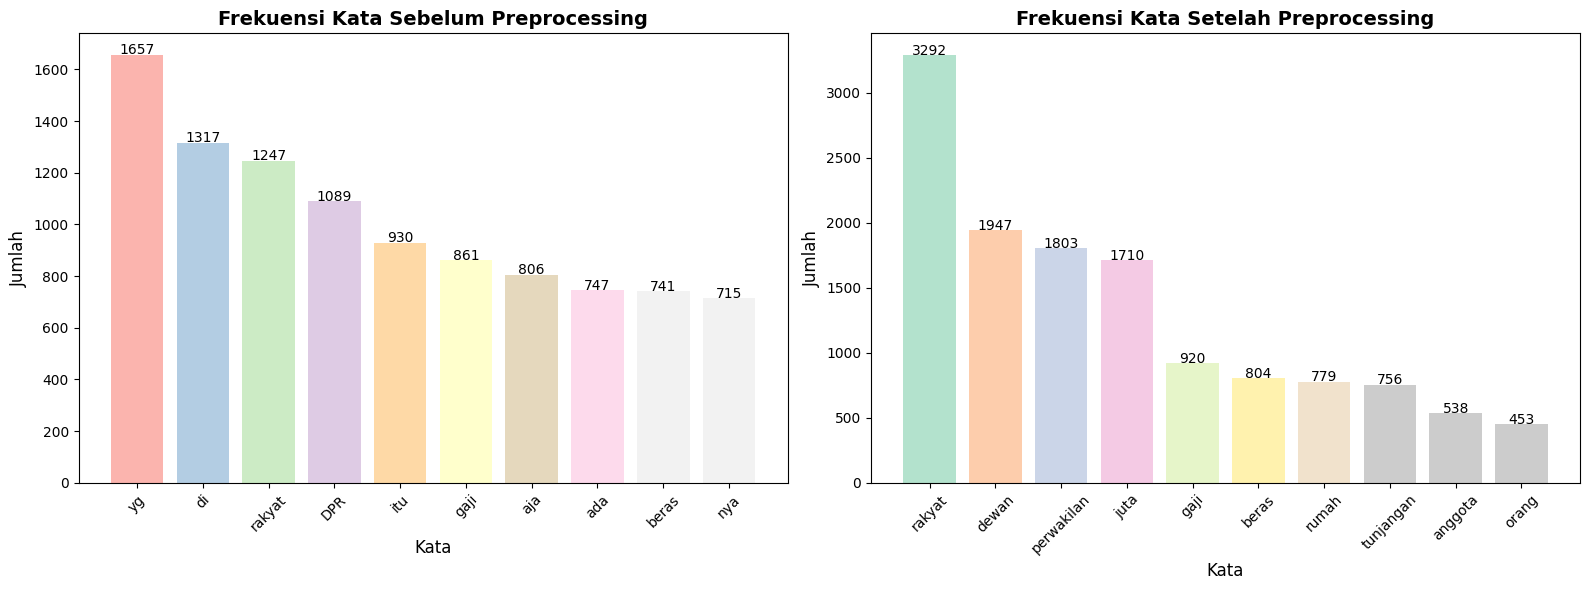

In [15]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS
import re

# Set stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi helper untuk membersihkan tanda kutip, [ ], , dll
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        # Hapus [ ], tanda petik tunggal/ganda, koma
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE
all_text_before = clean_text_column(df["comment"])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# AFTER
all_text_after = clean_text_column(df["stopword removal"])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE Plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

# AFTER Plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

In [16]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);

### PELABELAN DATA METODE LEXICON BASED 3 CLASS


In [17]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9985 entries, 0 to 9984
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment           9946 non-null   object
 1   cleaning          9572 non-null   object
 2   case_folding      9572 non-null   object
 3   normalisasi       9551 non-null   object
 4   tokenize          9985 non-null   object
 5   stopword removal  9396 non-null   object
dtypes: object(6)
memory usage: 468.2+ KB


,comment,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,yg setuju demo like,yg setuju demo like,yg setuju demo like,yang setuju demo like,"['yang', 'setuju', 'demo', 'like']",setuju demo like
1,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"['serius', 'bertanya', 'kalau', 'tidak', 'ada'...",serius dewan perwakilan rakyat orang hidup
2,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"['menari', 'di', 'atas', 'penderitaan', 'rakyat']",menari penderitaan rakyat
3,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"['dunia', 'akhirat', 'gue', 'tidak', 'iklas', ...",dunia akhirat gue iklas byr pajak
4,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"['tidak', 'usah', 'bayar', 'pajak', 'titikkkk']",bayar pajak titikkkk


In [18]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9396 entries, 0 to 9984
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment           9396 non-null   object
 1   cleaning          9396 non-null   object
 2   case_folding      9396 non-null   object
 3   normalisasi       9396 non-null   object
 4   tokenize          9396 non-null   object
 5   stopword removal  9396 non-null   object
dtypes: object(6)
memory usage: 513.8+ KB


In [19]:
data = pd.DataFrame(data[['stopword removal']])
data.head(5)

,stopword removal
0,setuju demo like
1,serius dewan perwakilan rakyat orang hidup
2,menari penderitaan rakyat
3,dunia akhirat gue iklas byr pajak
4,bayar pajak titikkkk


In [20]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['stopword removal'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(20)


,stopword removal,Score,Sentiment
0,setuju demo like,-1,Negatif
1,serius dewan perwakilan rakyat orang hidup,-2,Negatif
2,menari penderitaan rakyat,-1,Negatif
3,dunia akhirat gue iklas byr pajak,-1,Negatif
4,bayar pajak titikkkk,-1,Negatif
5,parah parah pejabat indonesiaa,-3,Negatif
6,rakyat sengsara anggota dewan perwakilan rakya...,-3,Negatif
7,bantuan listrik sumpah allah sakit hati denger...,3,Positif
8,allah ikhlas dunia akhirat gaji dewan perwakil...,0,Netral
9,orang orang prabowo pejabat kayak rakyat sengsara,-3,Negatif


C:\Users\sheva\AppData\Local\Temp\ipykernel_23456\1910355637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


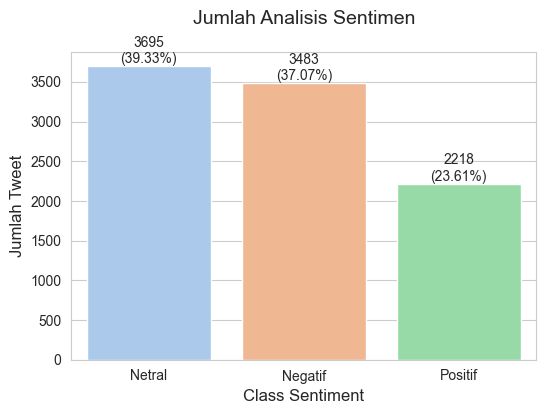

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [22]:
data.to_csv('Hasil_Labelling_Data_3class.csv',encoding='utf8', index=False)

### WordCLoud

In [23]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


,stopword removal,Score,Sentiment
0,setuju demo like,-1,Negatif
1,serius dewan perwakilan rakyat orang hidup,-2,Negatif
2,menari penderitaan rakyat,-1,Negatif
3,dunia akhirat gue iklas byr pajak,-1,Negatif
4,bayar pajak titikkkk,-1,Negatif


In [24]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


In [25]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,setuju demo like,Negatif
1,serius dewan perwakilan rakyat orang hidup,Negatif
2,menari penderitaan rakyat,Negatif
3,dunia akhirat gue iklas byr pajak,Negatif
4,bayar pajak titikkkk,Negatif


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stopword removal'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stopword removal'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stopword removal'].str.cat(sep=' ')

# Buat stopwords tambahan (termasuk kata penghubung/connector words)
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'jokowi',
    # Kata penghubung Bahasa Indonesia
    'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'adalah', 
    'ini', 'itu', 'pada', 'dengan', 'jika', 'seperti', 'karena', 
    'namun', 'tetapi', 'juga', 'tanpa', 'pun', 'saja', 'hanya', 
    'oleh', 'telah', 'sudah', 'akan', 'dapat', 'bisa', 'perlu', 
    'harus', 'tidak', 'ada', 'bukan', 'belum', 'lagi', 'lalu'
])

# Buat wordcloud untuk masing-masing sentimen
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(sentimen_Neutral)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds', stopwords=stopwords).generate(sentimen_Negative)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=stopwords).generate(sentimen_Positive)

# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white', stopwords=stopwords).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


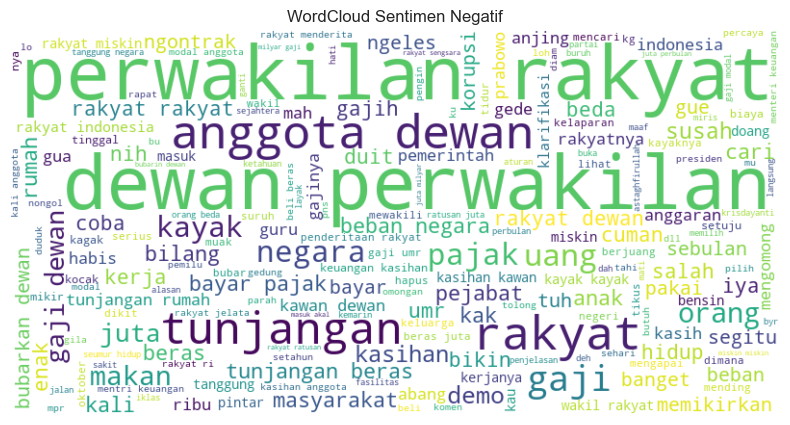

In [27]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

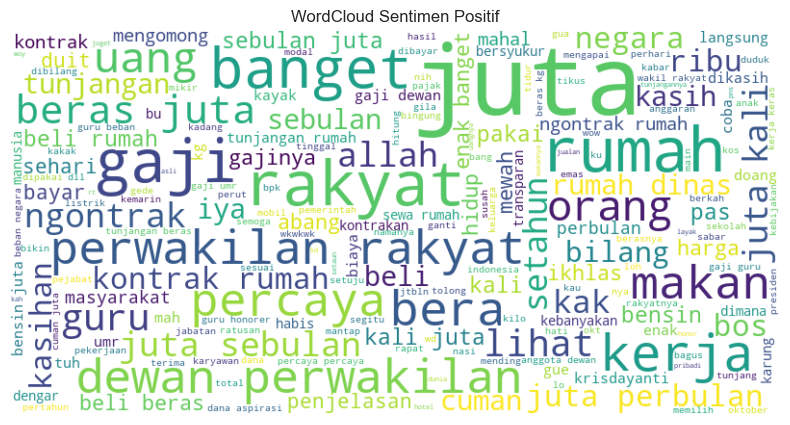

In [28]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

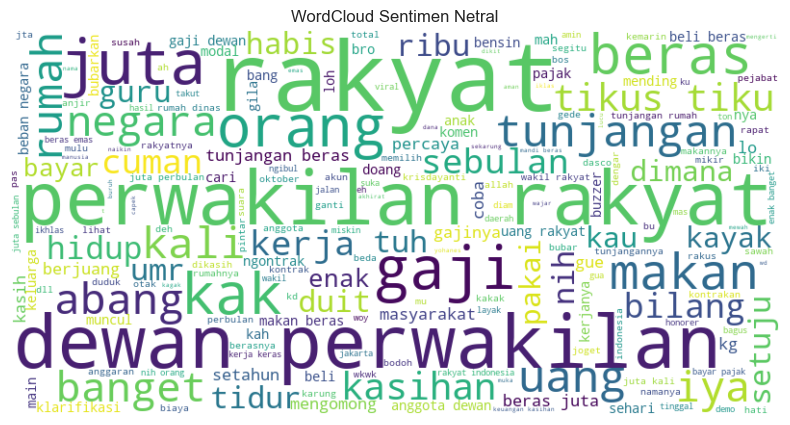

In [29]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

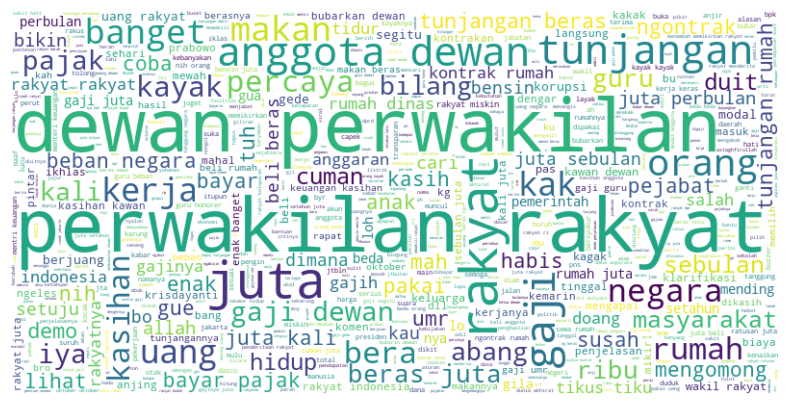

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# Mengisi nilai NaN dengan string kosong ('')
data['stopword removal'] = data['stopword removal'].fillna('')

# Menggabungkan teks dari kolom
text = ' '.join(data['stopword removal'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh',
    # Kata penghubung Bahasa Indonesia
    'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'adalah', 
    'ini', 'itu', 'pada', 'dengan', 'jika', 'seperti', 'karena', 
    'namun', 'tetapi', 'juga', 'tanpa', 'pun', 'saja', 'hanya', 
    'oleh', 'telah', 'sudah', 'akan', 'dapat', 'bisa', 'perlu', 
    'harus', 'tidak', 'ada', 'bukan', 'belum', 'lagi', 'lalu'
])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=1000, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


### Frekuensi Kata

In [31]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


,stopword removal,Score,Sentiment
0,setuju demo like,-1,Negatif
1,serius dewan perwakilan rakyat orang hidup,-2,Negatif
2,menari penderitaan rakyat,-1,Negatif
3,dunia akhirat gue iklas byr pajak,-1,Negatif
4,bayar pajak titikkkk,-1,Negatif


In [32]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


In [33]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,setuju demo like,Negatif
1,serius dewan perwakilan rakyat orang hidup,Negatif
2,menari penderitaan rakyat,Negatif
3,dunia akhirat gue iklas byr pajak,Negatif
4,bayar pajak titikkkk,Negatif


In [34]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stopword removal'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stopword removal'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stopword removal'].str.cat(sep=' ')

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh'])

# Fungsi hitung frekuensi kata + tampilkan jumlah
def plot_word_freq(text, title, color):
    words = [w for w in text.split() if w not in stopwords]
    word_freq = Counter(words).most_common(10)  # ambil 10 kata teratas
    df_freq = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(8,5))
    bars = plt.barh(df_freq['Kata'], df_freq['Frekuensi'], color=color)
    plt.gca().invert_yaxis()  # biar kata frekuensi tertinggi di atas
    plt.title(f"Top 10 Kata - Sentimen {title}", fontsize=14)
    plt.xlabel("Frekuensi")
    plt.ylabel("Kata")

    # Tambahkan label jumlah di ujung bar
    for bar in bars:
        plt.text(
            bar.get_width() + 0.2,  # posisi X sedikit ke kanan
            bar.get_y() + bar.get_height()/2,  # posisi Y di tengah bar
            str(int(bar.get_width())),  # nilai frekuensi
            va='center'
        )

    plt.show()

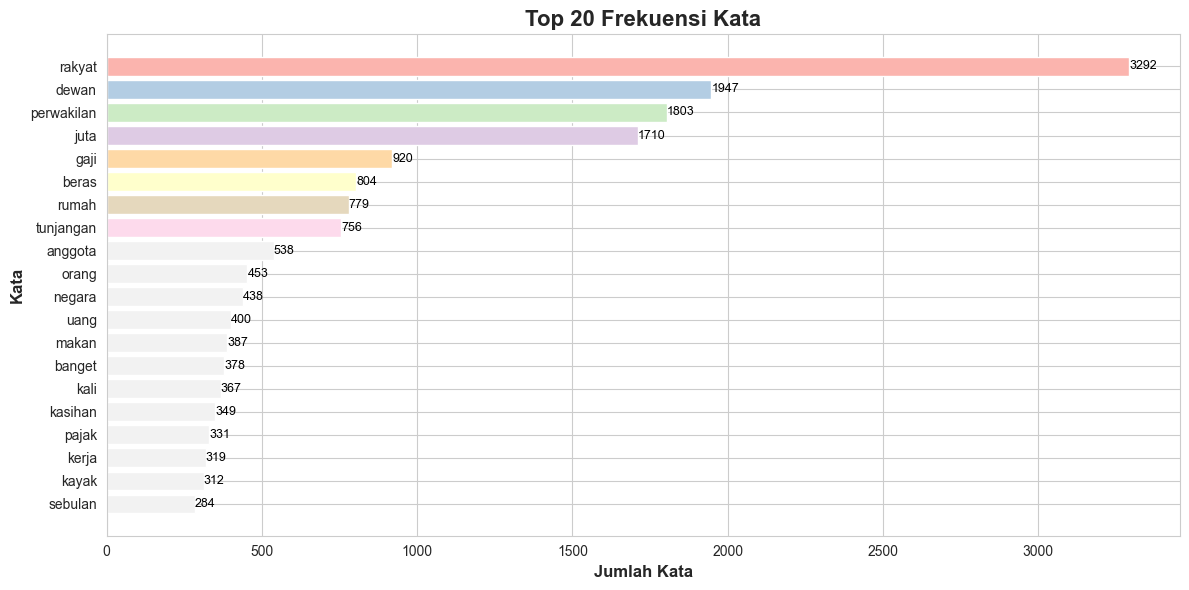

In [38]:
import matplotlib.pyplot as plt
from collections import Counter

# Gabungkan semua teks
text = " ".join(data["stopword removal"])

tokens = text.split()
word_counts = Counter(tokens)

# Ambil 20 kata teratas
top_words = word_counts.most_common(20)
word, count = zip(*top_words)

# Palet warna soft (Pastel)
colors = plt.cm.Pastel1(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.barh(word, count, color=colors)
plt.xlabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.ylabel("Kata", fontsize=12, fontweight='bold')
plt.title("Top 20 Frekuensi Kata", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Biar frekuensi tertinggi di atas

# Tambahkan angka di ujung bar
for bar, num in zip(bars, count):
    plt.text(num + 0.5, bar.get_y() + bar.get_height()/2,
             str(num), va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


### N-Gram Frekuensi Kata

In [39]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


,stopword removal,Score,Sentiment
0,setuju demo like,-1,Negatif
1,serius dewan perwakilan rakyat orang hidup,-2,Negatif
2,menari penderitaan rakyat,-1,Negatif
3,dunia akhirat gue iklas byr pajak,-1,Negatif
4,bayar pajak titikkkk,-1,Negatif


In [40]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


In [41]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,setuju demo like,Negatif
1,serius dewan perwakilan rakyat orang hidup,Negatif
2,menari penderitaan rakyat,Negatif
3,dunia akhirat gue iklas byr pajak,Negatif
4,bayar pajak titikkkk,Negatif


In [43]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Stopwords tambahan (termasuk kata penghubung/connector words Bahasa Indonesia)
custom_stopwords = set(ENGLISH_STOP_WORDS)
custom_stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'koruptor', 'ai', 'berapa', 'can',
    # Kata penghubung Bahasa Indonesia
    'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'adalah', 
    'ini', 'itu', 'pada', 'dengan', 'jika', 'seperti', 'karena', 
    'namun', 'tetapi', 'juga', 'tanpa', 'pun', 'saja', 'hanya', 
    'oleh', 'telah', 'sudah', 'akan', 'dapat', 'bisa', 'perlu', 
    'harus', 'tidak', 'ada', 'bukan', 'belum', 'lagi', 'lalu'
])

# Fungsi buat ambil n-gram
def get_top_ngrams(corpus, n=3, top_k=10, stopwords=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Fungsi buat plot frekuensi n-gram
def plot_ngrams(corpus, sentiment_label, color_map=plt.cm.Set2, stopwords=None):
    top_ngrams = get_top_ngrams(corpus, n=3, top_k=10, stopwords=stopwords)
    if not top_ngrams:
        print(f"Tidak ada trigram untuk sentimen {sentiment_label}")
        return

    ngrams, counts = zip(*top_ngrams)
    colors = color_map(range(len(ngrams)))

    plt.figure(figsize=(10,6))
    bars = plt.barh(ngrams, counts, color=colors)
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Trigram - Sentimen {sentiment_label}", fontsize=16, fontweight='bold')
    plt.xlabel("Jumlah Kemunculan", fontsize=12)
    plt.ylabel("Trigram", fontsize=12)

    # Tambahin label jumlah di ujung bar
    for bar, num in zip(bars, counts):
        plt.text(num + 0.01, bar.get_y() + bar.get_height()/2,
                 str(num), va='center', fontsize=11, color='black')

    plt.tight_layout()
    plt.show()


# Ambil data per sentimen
corpus_neg = data[data['Sentiment'] == 'Negatif']['stopword removal'].astype(str).tolist()
corpus_neu = data[data['Sentiment'] == 'Netral']['stopword removal'].astype(str).tolist()
corpus_pos = data[data['Sentiment'] == 'Positif']['stopword removal'].astype(str).tolist()


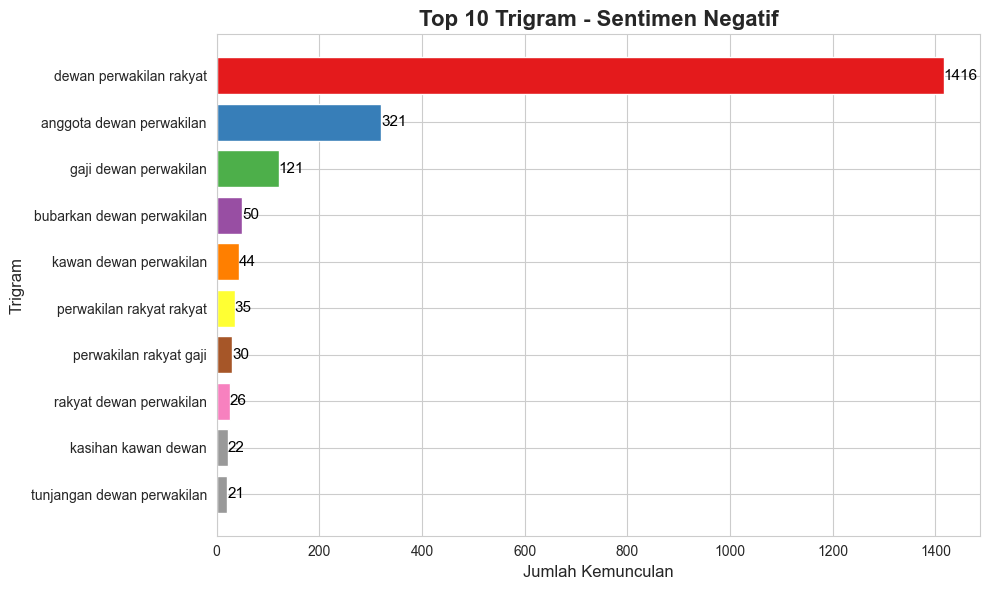

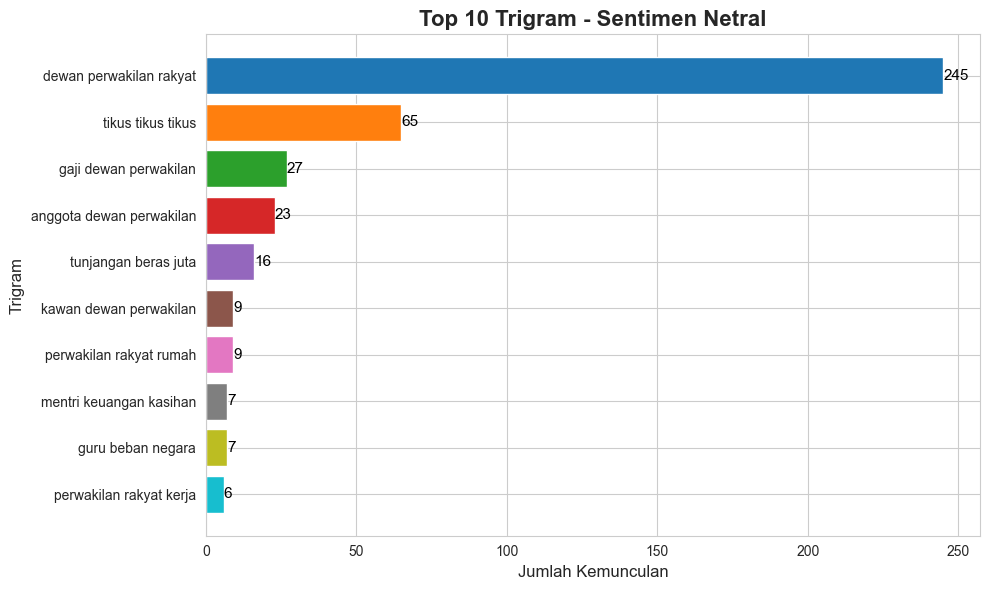

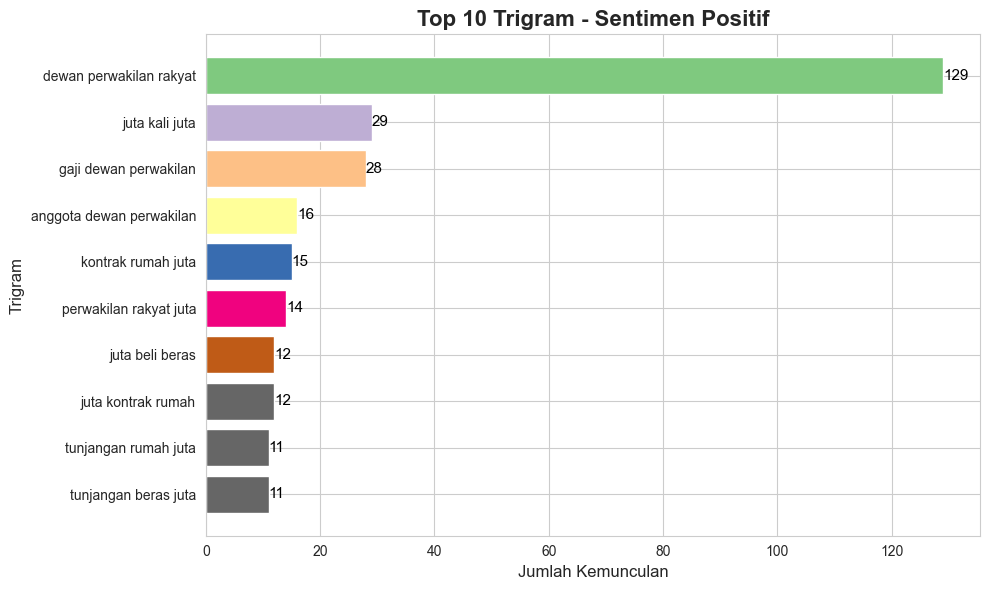

In [45]:
plot_ngrams(corpus_neg, "Negatif", plt.cm.Set1)
plot_ngrams(corpus_neu, "Netral", plt.cm.tab10)
plot_ngrams(corpus_pos, "Positif", plt.cm.Accent)

c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['rt'] not in stop_words.
  warnings.warn(


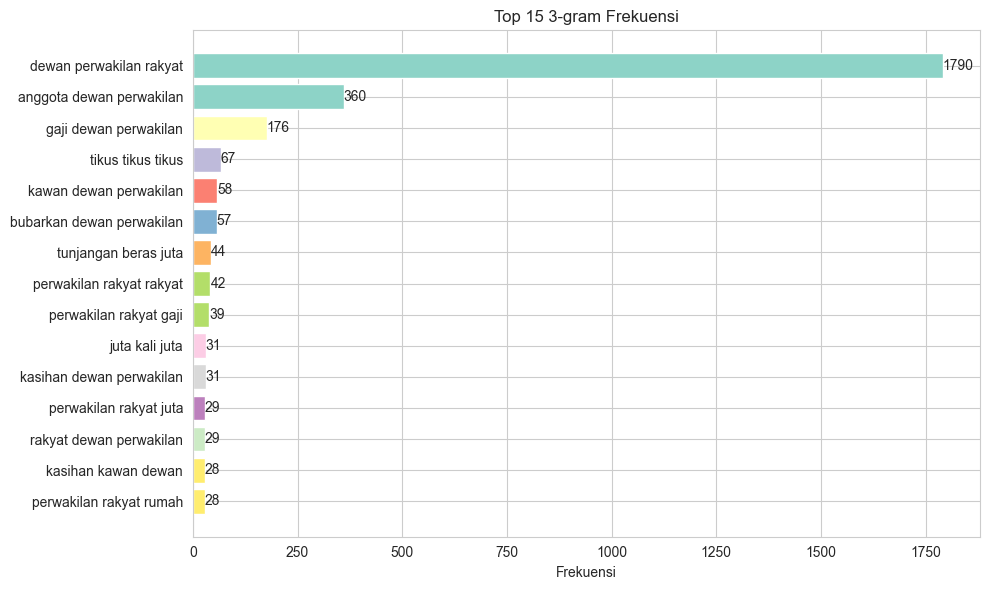

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Daftar stopwords tambahan (termasuk kata penghubung/connector words)
custom_stopwords = [
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'koruptor', 'ai', 'berapa', 'can',
    # Kata penghubung Bahasa Indonesia
    'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'adalah', 
    'ini', 'itu', 'pada', 'dengan', 'jika', 'seperti', 'karena', 
    'namun', 'tetapi', 'juga', 'tanpa', 'pun', 'saja', 'hanya', 
    'oleh', 'telah', 'sudah', 'akan', 'dapat', 'bisa', 'perlu', 
    'harus', 'tidak', 'ada', 'bukan', 'belum', 'lagi', 'lalu'
]

# Fungsi untuk membuat diagram batang frekuensi n-gram
def plot_ngram_frequencies(texts, ngram_range=(3,3), top_n=15, cmap=plt.cm.Set3):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=custom_stopwords)
    X = vectorizer.fit_transform(texts)

    # Hitung total frekuensi setiap n-gram
    ngram_counts = X.sum(axis=0).A1
    ngram_vocab = vectorizer.get_feature_names_out()
    freq_dist = dict(zip(ngram_vocab, ngram_counts))

    # Ambil n-gram dengan frekuensi tertinggi
    top_ngrams = Counter(freq_dist).most_common(top_n)
    labels, values = zip(*top_ngrams)

    # Buat warna berbeda untuk tiap bar
    colors = cmap(np.linspace(0, 1, len(labels)))

    # Visualisasi
    plt.figure(figsize=(10, 6))
    bars = plt.barh(labels[::-1], values[::-1], color=colors[::-1])
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Frekuensi')
    plt.xlabel('Frekuensi')

    # Tambahkan label angka di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width}', va='center')

    plt.tight_layout()
    plt.show()

# Contoh pemanggilan: Visualisasi 4-gram
plot_ngram_frequencies(data['stopword removal'], ngram_range=(3,3), top_n=15, cmap=plt.cm.Set3)


### IndoBERT FINETUNING

In [47]:
!pip install transformers datasets scikit-learn seaborn matplotlib torchvision

In [48]:
import os
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset

# Load data
df = pd.read_csv("Hasil_Labelling_Data_3class.csv")

df.info()
df.head(5)

c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


,stopword removal,Score,Sentiment
0,setuju demo like,-1,Negatif
1,serius dewan perwakilan rakyat orang hidup,-2,Negatif
2,menari penderitaan rakyat,-1,Negatif
3,dunia akhirat gue iklas byr pajak,-1,Negatif
4,bayar pajak titikkkk,-1,Negatif


In [49]:
df = df.dropna(subset=['stopword removal', 'Sentiment'])
# df = df[:1000]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  9396 non-null   object
 1   Score             9396 non-null   int64 
 2   Sentiment         9396 non-null   object
dtypes: int64(1), object(2)
memory usage: 220.3+ KB


In [50]:
# Encode label jika belum numerik
if df['Sentiment'].dtype == 'object':
    df['Sentiment'] = df['Sentiment'].astype('category').cat.codes

# Split data 80:20
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [51]:
# Tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(example):
    return {
        **tokenizer(example["stopword removal"], truncation=True),
        'labels': example['Sentiment']
    }

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 1880/1880 [00:00<00:00, 9609.15 examples/s]


In [52]:
pip install transformers[torch] accelerate>=0.26.0

Note: you may need to restart the kernel to use updated packages.


In [54]:
# Load IndoBERT for classification
model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=df['Sentiment'].nunique())

# Training arguments dengan learning rate adaptif
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [55]:
# Define compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
    }

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

C:\Users\sheva\AppData\Local\Temp\ipykernel_23456\2508360670.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [56]:
# Train
trainer.train()

#  Evaluate
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true = predictions.label_ids

c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.715900,0.463609,0.820745
2,0.362600,0.454974,0.858511
3,0.195800,0.583141,0.870745


c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\sheva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8707446808510638

Classification Report:
               precision    recall  f1-score   support

     Positif       0.91      0.89      0.90       695
      Netral       0.82      0.87      0.85       742
     Negatif       0.91      0.84      0.87       443

    accuracy                           0.87      1880
   macro avg       0.88      0.87      0.87      1880
weighted avg       0.87      0.87      0.87      1880



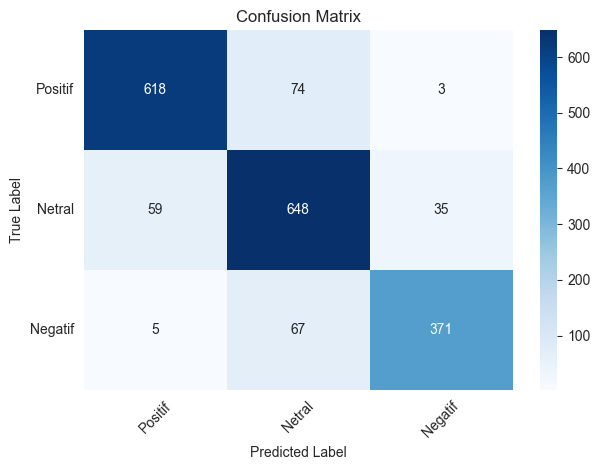

In [57]:
from sklearn.utils.multiclass import unique_labels

# Semua label sentimen sesuai grafik Anda
all_label_names = ['Positif', 'Netral', 'Negatif']

# Ambil label yang benar-benar ada di hasil prediksi
labels_in_data = sorted(list(unique_labels(true, preds)))
used_label_names = [all_label_names[i] for i in labels_in_data]

# Classification report & accuracy
print("Accuracy:", accuracy_score(true, preds))
print("\nClassification Report:\n", classification_report(true, preds, target_names=used_label_names))

# Confusion Matrix
cm = confusion_matrix(true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=used_label_names, yticklabels=used_label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()